# Event representations
In this notebook different event representations are generated and compared.
Representaitons used: event frame, timesurface, adaptive timesurface, voxel grids.

In [41]:
# imports
import sys
sys.path.append('../utils/')
sys.path.append('../simulator/src/')
import eventIO
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# load raw data
event_data = eventIO.load_hdf5('/data/lkolmar/datasets/topspin/data/01021/01021_events.hdf5')

## Event Frame
A simple visualization of all events inside a time window into an image<br>
There are two different options: -1/+1 for every pixel depending on its polarity.<br>
Doing accumulation -> see next part<br><br>
This ignores the fact that a pixel could have both polarities.

## Event Histogram
Same thing, but instead of clipping values to -1,1 All polarities per pixel are summed up. <br>
Also called event accumulation frame or event intensity frame

In [ ]:
# parameters
accumulation_time = 50 # in us
width = 1280
height = 720
histogram = False # if True, use histogram representation, else use event frame

# start generation
ts = event_data.get_ts()
x = event_data.get_x()
y = event_data.get_y()
p = event_data.get_p()

# define time frames using numpy for efficiency
num_frames = (ts[-1] - ts[0]) // accumulation_time + 1
frame_indices = ((ts - ts[0]) // accumulation_time).astype(np.int32)

frames = np.zeros((num_frames, height, width), dtype=np.int8)
# polarity: 0 -> -1, 1 -> +1
pol = p * 2 - 1
np.add.at(frames, (frame_indices, y, x), pol)

frames_hist = frames.copy()
np.clip(frames, -1, 1, out=frames) # clipping

frames = frames[:num_frames]

(1034, 720, 1280)
Unique values in frame 351: [-1  0  1]


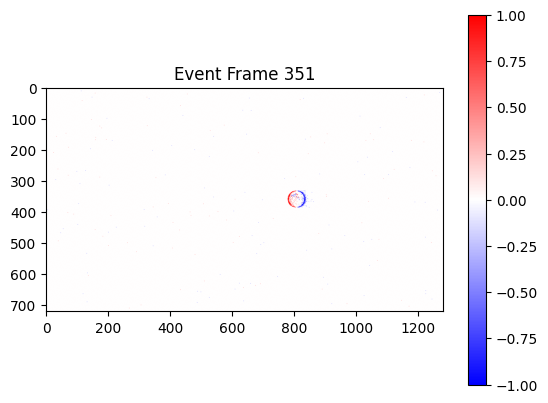

In [35]:
# visualie one random frame
print(frames.shape)
i = 351
print(f"Unique values in frame {i}: {np.unique(frames[i])}")
plt.imshow(frames[i], cmap='bwr', vmin=-1, vmax=1)
plt.title(f"Event Frame {i}")
plt.colorbar()
plt.show()

(1034, 720, 1280)
Unique values in histogram frame 351: [-4 -3 -2 -1  0  1  2  3  4]


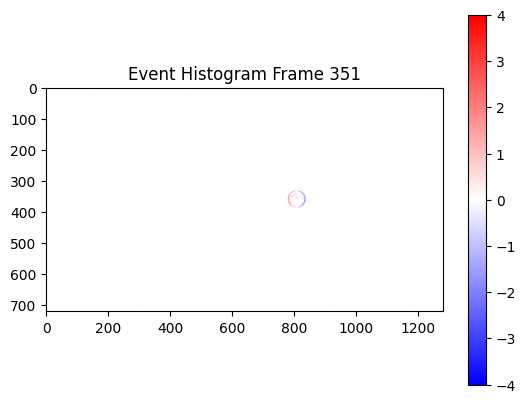

In [36]:
print(frames_hist.shape)
print(f"Unique values in histogram frame {i}: {np.unique(frames_hist[i])}")
plt.imshow(frames_hist[i], cmap='bwr')
plt.title(f"Event Histogram Frame {i}")
plt.colorbar()
plt.show()

## Time-surface

A way to inlcude spatial and temporal information into one image. <br>
The values of each pixel get decayed depending on how recent it activated <br>
I dont fully understand if the intention would be haveing one timesurface for the entire recording or using time bins as well

Generated 104 time-surface frames.


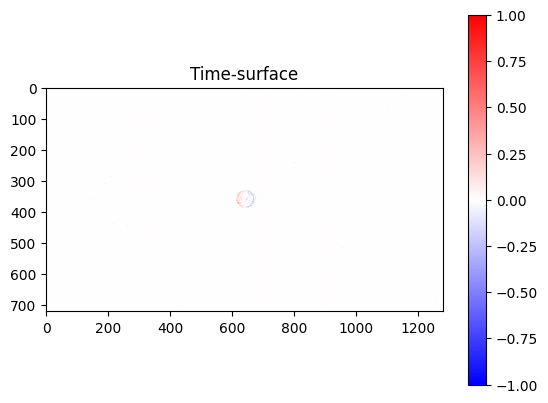

In [58]:
# parameters
accumulation_time = 500 # in us
width = 1280
height = 720
tau = 10 # 50 us

# Vectorized time-surface computation using numpy (no explicit Python loop)
frame_edges = np.arange(ts[0], ts[-1] + accumulation_time, accumulation_time)
frame_count = len(frame_edges) - 1

# For each event, find which frame it belongs to
event_frame_indices = np.searchsorted(frame_edges, ts, side='right') - 1

# Compute reference time for each frame
t_ref = frame_edges[1:] - 1  # last timestamp in each frame

# Compute decay for all events at once
decay = np.exp(-(t_ref[event_frame_indices] - ts) / tau)
pol = np.where(p > 0, 1.0, -1.0)
values = decay * pol

# Accumulate into frames (vectorized)
frames = np.zeros((frame_count, height, width), dtype=np.float32)
np.add.at(frames, (event_frame_indices, y, x), values)

print(f"Generated {len(frames)} time-surface frames.")
plt.imshow(frames[50], cmap='bwr', vmin=-1, vmax=1)
plt.title("Time-surface")
plt.colorbar()
plt.show()

## EROS
There is a paper for it. Also Thomas used it in his version of spin estimation.<br>


In [ ]:
# TODO

## Voxel Grid
Max used this representation in his Thesis. <br>
https://github.com/TimoStoff/event_utils/tree/master?tab=readme-ov-file<br>
As far as i uderstood it now, this is just the discretization of the time dimension -> putting events into bins instead of haveng t as value. <br>
